Statistics Project
To analyze customer behavior using statistical and mathematical tools in Python, to
identify factors affecting customer retention and churn.  
Get the dataset from :
https://drive.google.com/file/d/1VX-LFyvlpQf7T_6lMnco0DKn6-5PtA1q/view?usp=
drive_link


Dataset Description:
Assume a dataset with the following columns:
1. CustomerID
2. Gender
3. Region
4. PurchaseAmount
5. ProductCategory
6. Churn (Yes/No)
7. CampaignGroup (A/B)


Questions  
1. What is the average, median, and mode of PurchaseAmount?
2. Are there any outliers in the PurchaseAmount data?
3. Is there any skewness or kurtosis in the PurchaseAmount distribution?
4. Is there a significant difference in spending between male and female
customers?
5. Is there a relationship between ProductCategory and customer churn?
6. Does PurchaseAmount vary significantly across different regions?
7. Which email campaign (A or B) performed better in terms of average
PurchaseAmount?
8. Can we assume PurchaseAmount follows a normal distribution?
9. What insights can we gain by applying the Central Limit Theorem?
10. What is the 95% confidence interval for the average PurchaseAmount?

Statistics Project To analyze customer behavior using statistical and mathematical tools in Python, to identify factors affecting customer retention and churn.

Customer churn occurs when a customer stops using a company’s service lead to revenue loss. Analyzing churn helps businesses understand why customers leave and how to improve retention. High churn rates can affect revenue and business growth. By analyzing churn patterns businesses can take proactive steps to retain customers.
for that purpose following step is followed--
Importing Libraries and Dataset,
 Understanding the Dataset,
 Analyzing Churn Distribution,
  Data Preprocessing(Handling Missing and Incorrect Values),
  Handling Categorical Variables,
   Model Training and Prediction,
   Model Evaluation,


Customer Behaviour Data Set

In [ ]:
import pandas as pd
df = pd.read_excel("Customer Behaviour.xlsx")
df

,CustomerID,Gender,Region,PurchaseAmount,ProductCategory,Churn,CampaignGroup
0,1001,Male,South,256.07,Fashion,No,A
1,1002,Female,South,NaN,Electronics,Yes,B
2,1003,Female,West,1194.41,Fashion,No,A
3,1004,Female,South,413.06,Grocery,No,A
4,1005,Male,West,1556.32,Fashion,Yes,A
...,...,...,...,...,...,...,...
4995,5996,Female,West,1497.00,Electronics,Yes,B
4996,5997,Male,West,978.87,Fashion,Yes,A
4997,5998,Male,West,906.93,Fashion,No,NaN
4998,5999,Female,South,375.67,Fashion,No,NaN


What is the average, median, and mode of PurchaseAmount?

Average/Mean value

In [ ]:
import pandas as pd
df = pd.read_excel("Customer Behaviour.xlsx")
import statistics

purchase_amounts = df["PurchaseAmount"].dropna()

if not purchase_amounts.empty:

    average_amount = statistics.mean(purchase_amounts)

    rounded_average = round(average_amount, 2)

    print(f"The average/mean value of purchase amount is: ${rounded_average}")
else:
    print("There are no valid 'PurchaseAmount' values to calculate the average.")

The average/mean value of purchase amount is: $1003.95


Median

In [ ]:
import pandas as pd
df = pd.read_excel("Customer Behaviour.xlsx")
import statistics

purchase_amounts = df["PurchaseAmount"].dropna()

if not purchase_amounts.empty:

    median_amount = statistics.median(purchase_amounts)

    rounded_median = round(median_amount, 2)

    print(f"The median of purchase amount is: ${rounded_median}")
else:
    print("There are no valid 'PurchaseAmount' values to calculate the median.")

The median of purchase amount is: $998.08


Mode

In [ ]:
import pandas as pd
df = pd.read_excel("Customer Behaviour.xlsx")
import statistics

purchase_amounts = df["PurchaseAmount"].dropna()

if not purchase_amounts.empty:

    mode_amount = statistics.mode(purchase_amounts)

    rounded_mode = round(mode_amount, 2)

    print(f"The mode of purchase amount is: ${rounded_mode}")
else:
    print("There are no valid 'PurchaseAmount' values to calculate the mode.")

The mode of purchase amount is: $0.0


Are there any outliers in the PurchaseAmount data?

In [ ]:
import pandas as pd
df = pd.read_excel("Customer Behaviour.xlsx")
df['PurchaseAmount']

,PurchaseAmount
0,256.07
1,NaN
2,1194.41
3,413.06
4,1556.32
...,...
4995,1497.00
4996,978.87
4997,906.93
4998,375.67


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_excel("Customer Behaviour.xlsx")
purchase_amounts = df['PurchaseAmount'].dropna()

if not purchase_amounts.empty:

    Q1 = purchase_amounts.quantile(0.25)
    Q3 = purchase_amounts.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = purchase_amounts[(purchase_amounts < lower_bound) | (purchase_amounts > upper_bound)]

    if not outliers.empty:
        print("Outliers in PurchaseAmount:")
        print(outliers)
    else:
        print("No outliers detected in PurchaseAmount based on the IQR method.")
else:
    print("No valid 'PurchaseAmount' data available after dropping NaNs to check for outliers.")

Outliers in PurchaseAmount:
195     2318.33
265     2496.41
348     2688.69
411     2349.16
826     2578.89
1358    2384.19
2285    2457.05
2557    2316.19
2681    2400.69
3326    2357.41
3438    2688.88
3564    2643.88
4345    2472.62
4693    2484.75
4808    2642.06
Name: PurchaseAmount, dtype: float64


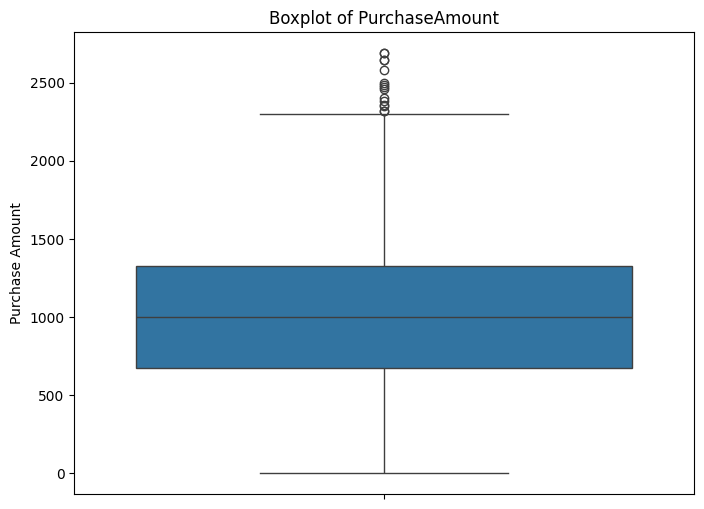

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_excel("Customer Behaviour.xlsx")

purchase_amounts_cleaned = df['PurchaseAmount'].dropna()

if not purchase_amounts_cleaned.empty:

    plt.figure(figsize=(8, 6))
    sns.boxplot(y=purchase_amounts_cleaned)
    plt.title('Boxplot of PurchaseAmount')
    plt.ylabel('Purchase Amount')
    plt.show()
else:
    print("No valid 'PurchaseAmount' data available to plot after removing NaNs.")


Is there any skewness or kurtosis in the PurchaseAmount distribution?

Skewness

In [ ]:
import pandas as pd
df = pd.read_excel("Customer Behaviour.xlsx")
df['PurchaseAmount']

from scipy.stats import skew

dataset = df['PurchaseAmount'].dropna()

# Calculate the skewness
print(skew(dataset, axis=0, bias=True))

0.10605907900111372


Kurtosis

In [ ]:
import pandas as pd
df = pd.read_excel("Customer Behaviour.xlsx")
df['PurchaseAmount']
from scipy.stats import kurtosis
dataset = df['PurchaseAmount'].dropna()
# Calculate the kurtosis
print(kurtosis(dataset, axis=0, bias=True))

-0.26247789221265183


Is there a significant difference in spending between male and female customers?

Male Average Spending: $1019.18
Female Average Spending: $987.87
T-statistic: 2.2349
P-value: 0.0255
Result: The difference in spending is statistically significant.


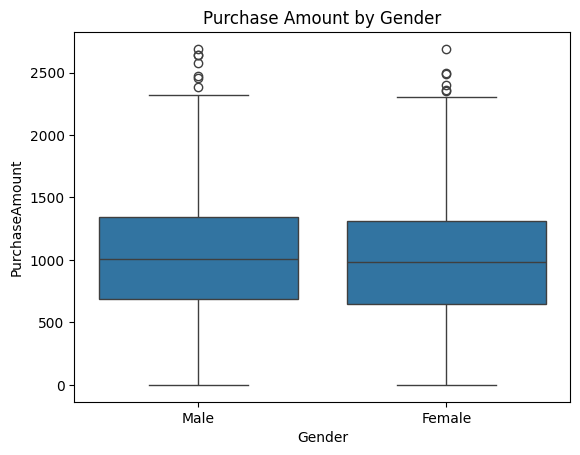

In [ ]:
import pandas as pd
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("Customer Behaviour.xlsx")

male_spending = df[df['Gender'] == 'Male']['PurchaseAmount'].dropna()
female_spending = df[df['Gender'] == 'Female']['PurchaseAmount'].dropna()

t_statistic, p_value = ttest_ind(male_spending, female_spending, nan_policy='omit')

print(f"Male Average Spending: ${male_spending.mean():.2f}")
print(f"Female Average Spending: ${female_spending.mean():.2f}")
print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Result: The difference in spending is statistically significant.")
else:
    print("Result: There is no statistically significant difference in spending between genders in this dataset.")

sns.boxplot(x='Gender', y='PurchaseAmount', data=df.dropna(subset=['PurchaseAmount', 'Gender']))
plt.title('Purchase Amount by Gender')
plt.show()

Is there a relationship between ProductCategory and customer churn?

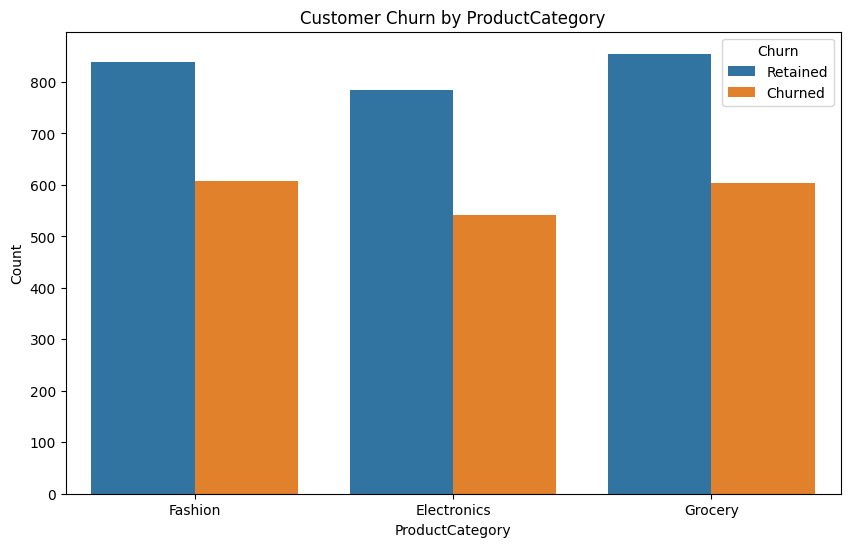

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("Customer Behaviour.xlsx")

def plot_churn_by_category(df, category_col, churn_col):
    """
    Plots the count of churned vs non-churned customers per product category.
    """
    plt.figure(figsize=(10, 6))
    sns.countplot(x=category_col, hue=churn_col, data=df)
    plt.title(f'Customer Churn by {category_col}')
    plt.xlabel(category_col)
    plt.ylabel('Count')
    plt.legend(title=churn_col, labels=['Retained', 'Churned'])
    plt.show()

plot_churn_by_category(df, 'ProductCategory', 'Churn')

Does PurchaseAmount vary significantly across different regions?

In [ ]:
import pandas as pd
df = pd.read_excel("Customer Behaviour.xlsx")
compare = df.groupby('Region')['PurchaseAmount'].mean()
print(compare)


Region
East     1009.946017
North    1013.017952
South     997.603877
West      995.247327
Name: PurchaseAmount, dtype: float64


Which email campaign (A or B) performed better in terms of average PurchaseAmount?

In [ ]:
import pandas as pd
df = pd.read_excel("Customer Behaviour.xlsx")
compare = df.groupby('CampaignGroup')['PurchaseAmount'].mean()
print(compare)


CampaignGroup
A    1011.945587
B     994.339965
Name: PurchaseAmount, dtype: float64


A is better

Can we assume PurchaseAmount follows a normal distribution?

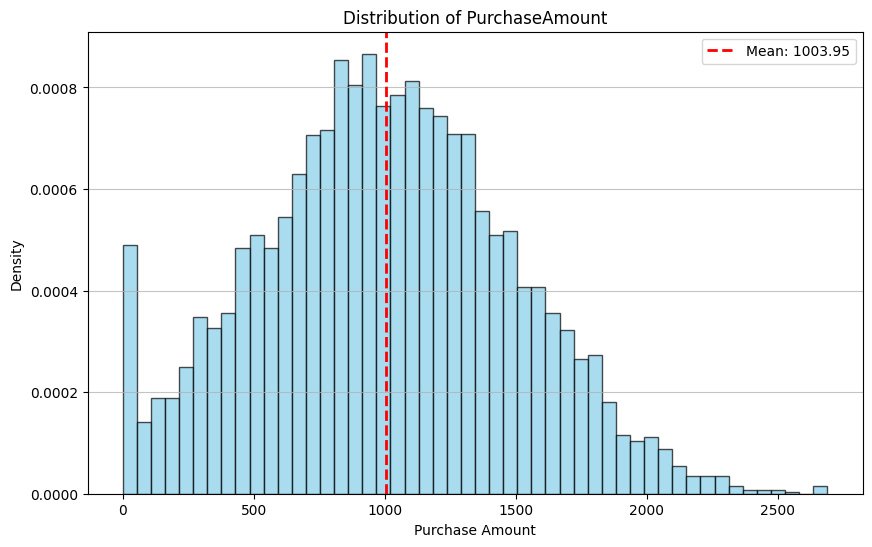

Mean of PurchaseAmount: 1003.95
Standard Deviation of PurchaseAmount: 482.11
Skewness of PurchaseAmount: 0.1061
Kurtosis of PurchaseAmount: -0.2625
Shapiro-Wilk Test Statistic: 0.9950
Shapiro-Wilk P-value: 0.0000
Conclusion: Based on Shapiro-Wilk test (p < 0.05), we reject the null hypothesis that PurchaseAmount is normally distributed.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro, skew, kurtosis

df = pd.read_excel("Customer Behaviour.xlsx")

purchase_amounts = df['PurchaseAmount'].dropna()

if not purchase_amounts.empty:

    actual_mean = purchase_amounts.mean()
    actual_std = purchase_amounts.std()

    plt.figure(figsize=(10, 6))
    plt.hist(purchase_amounts, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
    plt.title('Distribution of PurchaseAmount')
    plt.xlabel('Purchase Amount')
    plt.ylabel('Density')

    plt.axvline(actual_mean, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {actual_mean:.2f}')
    plt.legend()
    plt.grid(axis='y', alpha=0.75)
    plt.show()

    print(f"Mean of PurchaseAmount: {actual_mean:.2f}")
    print(f"Standard Deviation of PurchaseAmount: {actual_std:.2f}")
    print(f"Skewness of PurchaseAmount: {skew(purchase_amounts):.4f}")
    print(f"Kurtosis of PurchaseAmount: {kurtosis(purchase_amounts):.4f}")

    if len(purchase_amounts) >= 3:
        shapiro_stat, shapiro_p = shapiro(purchase_amounts)
        print(f"Shapiro-Wilk Test Statistic: {shapiro_stat:.4f}")
        print(f"Shapiro-Wilk P-value: {shapiro_p:.4f}")

        alpha = 0.05
        if shapiro_p < alpha:
            print("Conclusion: Based on Shapiro-Wilk test (p < 0.05), we reject the null hypothesis that PurchaseAmount is normally distributed.")
        else:
            print("Conclusion: Based on Shapiro-Wilk test (p > 0.05), we fail to reject the null hypothesis, suggesting PurchaseAmount might be normally distributed.")
    else:
        print("Not enough data to perform Shapiro-Wilk test for normality (requires at least 3 data points).")

else:
    print("No valid 'PurchaseAmount' data available to analyze or plot.")

What insights can we gain by applying the Central Limit Theorem?


Answer: Mean and Standard Deviation

Understanding the Behavior of Sample Means,
Validating Statistical Assumptions (Inferential Statistics),
Quantifying Uncertainty (Confidence Intervals),
Practical Demonstration of a Key Mathematical Concept,
Foundation for Hypothesis Testing

Central Limit Theorem (CLT) is a key concept in statistics that explains why many distributions tend to look like a normal distribution when averaged. It states that if you take a large number of random samples from any population, the distribution of their means will be approximately normal, even if the original population is not. Implementing it using Python can significantly enhance data analysis capabilities
Import Required Libraries,Set Sample Sizes and Initialize Storage,Set Random Seed for Reproducibility and Generate Sample Means for Each Sample Size,Plot Distributions

What is the 95% confidence interval for the average PurchaseAmount?

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as st

df = pd.read_excel("Customer Behaviour.xlsx")

def calculate_confidence_interval(purchase_amounts_clean, confidence_level=0.95):
    """
    Calculates the confidence interval for the mean of a dataset.

    Args:
        purchase_amounts_clean (pd.Series or np.array): A Series or array of purchase amounts (should be clean of NaNs).
        confidence_level (float): The desired confidence level (e.g., 0.95 for 95%).

    Returns:
        tuple: (lower_bound, upper_bound) of the confidence interval.
    """
    if purchase_amounts_clean.empty:
        return np.nan, np.nan

    sample_mean = np.mean(purchase_amounts_clean)
    sample_size = len(purchase_amounts_clean)
    degrees_of_freedom = sample_size - 1

    standard_error = st.sem(purchase_amounts_clean)

    ci_lower, ci_upper = st.t.interval(confidence=confidence_level,
                                       df=degrees_of_freedom,
                                       loc=sample_mean,
                                       scale=standard_error)

    return ci_lower, ci_upper

sample_purchase_amounts = df['PurchaseAmount'].dropna()

lower_bound, upper_bound = calculate_confidence_interval(sample_purchase_amounts, confidence_level=0.95)

print(f"Sample Mean Purchase Amount: ${np.mean(sample_purchase_amounts):.2f}")
if not np.isnan(lower_bound):
    print(f"95% Confidence Interval: (${lower_bound:.2f}, ${upper_bound:.2f})")
else:
    print("Cannot calculate confidence interval due to insufficient data after dropping NaNs.")

Sample Mean Purchase Amount: $1003.95
95% Confidence Interval: ($990.38, $1017.52)


Sir, if any mistake just notify me i will resubmit my assignment